   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 23.6 MB/s eta 0:00:00
Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64

--- Data Diagnostics ---
Highest Average Return: TATAMOTORS.csv (Rate: 0.0070, Risk: 0.0624)

Solving for Markowitz Efficient Frontier...


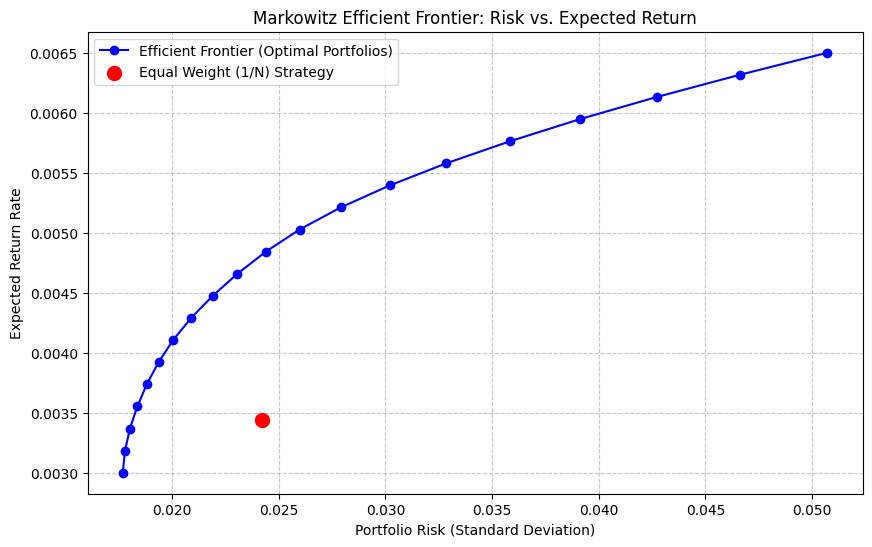

In [8]:
# ==========================================
# 0. Install Dependencies (Colab Environment)
# ==========================================
!pip install -q pyomo idaes-pse
!idaes get-extensions
import os
os.environ['PATH'] += ":/root/.idaes/bin"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import *
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading & Statistical Estimation
# ==========================================
df = pd.read_csv('Closing_Prices_5yrs.csv')
if 'Date' in df.columns:
    df.set_index('Date', inplace=True)

returns_5d = df.pct_change(periods=4).dropna()
mu = returns_5d.mean()
Sigma = returns_5d.cov()
stocks = returns_5d.columns.tolist()

print("--- Data Diagnostics ---")
best_stock = mu.idxmax()
print(f"Highest Average Return: {best_stock} (Rate: {mu.max():.4f}, Risk: {returns_5d.std()[best_stock]:.4f})")

# ==========================================
# 2. Markowitz Portfolio Optimization (Pyomo)
# ==========================================
M = 100000  # Total Investment Budget

model = ConcreteModel()
model.S = Set(initialize=stocks)
model.x = Var(model.S, domain=NonNegativeReals)
model.target_return_rate = Param(mutable=True, default=0.00025)

def variance_rule(model):
    return sum(model.x[i] * model.x[j] * Sigma.loc[i, j] for i in model.S for j in model.S)
model.risk_sq = Objective(rule=variance_rule, sense=minimize)

model.budget_con = Constraint(expr=sum(model.x[i] for i in model.S) == M)

def return_rule(model):
    return sum(mu[i] * model.x[i] for i in model.S) >= model.target_return_rate * M
model.return_con = Constraint(rule=return_rule)

# ==========================================
# 3. Solving the Efficient Frontier
# ==========================================
solver = SolverFactory('ipopt', executable='/root/.idaes/bin/ipopt')

target_returns = np.linspace(0.003, 0.0065, 20)
risk_data = []
return_data = []

print("\nSolving for Markowitz Efficient Frontier...")
for target in target_returns:
    model.target_return_rate = target
    results = solver.solve(model, tee=False)

    if results.solver.termination_condition == TerminationCondition.optimal:
        current_risk = np.sqrt(value(model.risk_sq)) / M
        current_return_rate = sum(mu[s] * value(model.x[s]) for s in stocks) / M

        risk_data.append(current_risk)
        return_data.append(current_return_rate)

# ==========================================
# 4. Equal Allocation Benchmark (1/N Strategy)
# ==========================================
weights_equal = np.repeat(1/len(stocks), len(stocks))
expected_return_equal = np.dot(weights_equal, mu)
variance_equal = np.dot(weights_equal.T, np.dot(Sigma, weights_equal))
risk_equal = np.sqrt(variance_equal)

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(risk_data, return_data, 'b-o', label='Efficient Frontier (Optimal Portfolios)')
plt.scatter(risk_equal, expected_return_equal, color='red', s=100, zorder=5, label='Equal Weight (1/N) Strategy')

plt.title('Markowitz Efficient Frontier: Risk vs. Expected Return')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Return Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()